# PaliGemma 2 — Uygulamalı Örnekler

Blog yazısına eşlik eden notebook. Altı örnek:

1. **SigLIP ve CLIP:** sigmoid olasılıkları neden 1'e toplanmıyor?
2. **Görsel token sayısı ve prefix-LM maskesi**
3. **Altyazı:** `caption en` ve `caption tr`
4. **Görsel soru-cevap:** `answer en ...`
5. **OCR:** Türkçe karakterler + 224 / 448 çözünürlük karşılaştırması (en sonda)
6. **Nesne tespiti:** `detect ...` çıktısındaki `<loc>` token'larını kutuya çevirmek

**Başlamadan önce:**
- *Runtime → Change runtime type → T4 GPU* seç.
- Hugging Face'te [google/paligemma2-3b-mix-448](https://huggingface.co/google/paligemma2-3b-mix-448) sayfasında lisansı kabul et (aynı hesapla `-224` sürümü de açılır).
- Colab'de soldaki 🔑 *Secrets* paneline `HF_TOKEN` adıyla Hugging Face token'ını ekle ve notebook erişimini aç.

In [1]:
!pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 35.4 MB/s eta 0:00:00


Cihaz: cuda


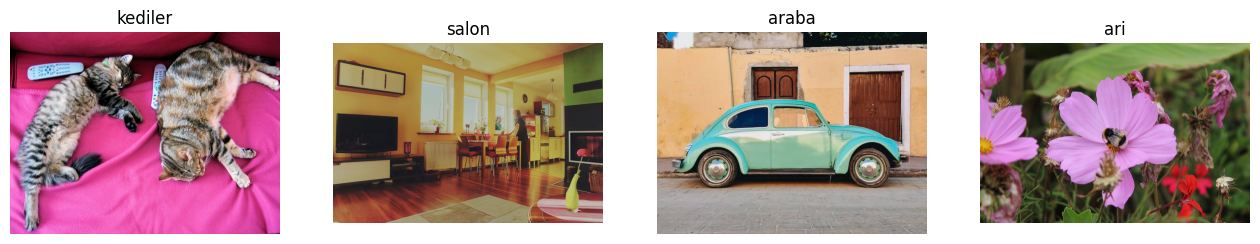

In [3]:
import os, re, requests, torch
from io import BytesIO
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Cihaz:", device)

def load(url):
    r = requests.get(url, headers={"User-Agent": "paligemma-colab-demo"}, timeout=30)
    r.raise_for_status()
    return Image.open(BytesIO(r.content)).convert("RGB")

imgs = {
    "kediler": load("http://images.cocodataset.org/val2017/000000039769.jpg"),
    "salon":   load("http://images.cocodataset.org/val2017/000000000139.jpg"),
    "araba":   load("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"),
    "ari":     load("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/bee.jpg"),
}

fig, axes = plt.subplots(1, len(imgs), figsize=(16, 4))
for ax, (name, im) in zip(axes, imgs.items()):
    ax.imshow(im); ax.set_title(name); ax.axis("off")
plt.show()

## 1. SigLIP ve CLIP: softmax ile sigmoid farkı

CLIP her görsel için tüm metinler üzerinde **softmax** alır: metinler olasılık için birbiriyle yarışır ve toplam her zaman 1 olur.
SigLIP ise her (görsel, metin) çiftini **ayrı bir evet/hayır sorusu** olarak ele alır ve her hücreye kendi sigmoid'ini uygular.

Deney: iki kedili fotoğrafa birbiriyle çelişmeyen doğru metinler veriyoruz ("kedi", "iki kedi", "hayvan").
- CLIP'te bu doğru metinler olasılığı **paylaşmak zorunda.**
- SigLIP'te hepsi **aynı anda** yüksek çıkabilir.

> Not: `siglip-so400m` metin tarafında yalnızca İngilizce bildiği için metinler İngilizce. SigLIP'e metni mutlaka `padding="max_length"` ile vermek gerekiyor, çünkü model bu şekilde eğitildi.

In [4]:
from transformers import AutoModel, AutoProcessor, CLIPModel, CLIPProcessor

texts = ["a photo of a cat", "a photo of two cats", "a photo of an animal",
         "a photo of a dog", "a photo of a car"]
image = imgs["kediler"]

# SigLIP: her hücre bağımsız sigmoid
sig_id = "google/siglip-so400m-patch14-384"
sig_model = AutoModel.from_pretrained(sig_id).to(device).eval()
sig_proc = AutoProcessor.from_pretrained(sig_id)
with torch.no_grad():
    x = sig_proc(text=texts, images=image, padding="max_length", return_tensors="pt").to(device)
    sig_probs = torch.sigmoid(sig_model(**x).logits_per_image)[0].cpu()

# CLIP: satır boyunca softmax
clip_id = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_id).to(device).eval()
clip_proc = CLIPProcessor.from_pretrained(clip_id)
with torch.no_grad():
    x = clip_proc(text=texts, images=image, padding=True, return_tensors="pt").to(device)
    clip_probs = clip_model(**x).logits_per_image.softmax(dim=-1)[0].cpu()

print(f"{'metin':28s} {'SigLIP (sigmoid)':>17s} {'CLIP (softmax)':>15s}")
for t, s, c in zip(texts, sig_probs, clip_probs):
    print(f"{t:28s} {s:17.3f} {c:15.3f}")
print(f"{'TOPLAM':28s} {sig_probs.sum():17.3f} {clip_probs.sum():15.3f}")

config.json:   0%|          | 0.00/576 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.51GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

metin                         SigLIP (sigmoid)  CLIP (softmax)
a photo of a cat                         0.006           0.029
a photo of two cats                      0.413           0.968
a photo of an animal                     0.000           0.003
a photo of a dog                         0.000           0.000
a photo of a car                         0.000           0.000
TOPLAM                                   0.420           1.000


**Okuma:** CLIP'te toplam her zaman 1. Doğru olan üç metin olasılığı aralarında bölüşüyor, yani "hangisi doğru?" sorusu soruluyor.
SigLIP'te ise her satır kendi başına "bu çift eşleşiyor mu?" sorusuna cevap veriyor. Toplamın 1 olması gerekmiyor; doğru metinlerin hepsi birden yüksek çıkabiliyor.
PaliGemma'nın görüntü kodlayıcısı bu SigLIP modeli. Kontrastif kafası atılıyor, yalnızca görüntü kodlayıcı tarafı kullanılıyor.

In [5]:
# Bellekte yer açmak için SigLIP ve CLIP'i siliyoruz
del sig_model, clip_model
import gc; gc.collect(); torch.cuda.empty_cache()

## PaliGemma 2'yi yükleme

Doğrudan görev çalıştırmak için `mix` checkpoint'i kullanıyoruz. `pt` checkpoint'leri ince ayar (fine-tune) için tasarlandı; onlara sıfırdan görev verince sonuçlar zayıf olur.
3B model `bfloat16` ile yaklaşık 6 GB tutar ve T4'e sığar.

In [6]:
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor

MODEL_ID = "google/paligemma2-3b-mix-448"
model = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto").eval()
proc = PaliGemmaProcessor.from_pretrained(MODEL_ID)

def ask(img, prompt, max_new_tokens=100, raw=False, m=None, p=None):
    """Görsel + görev önekiyle cevap üretir. raw=True verilirse <loc>/<seg> token'ları silinmeden döner."""
    m, p = m or model, p or proc
    x = p(text="<image>" + prompt, images=img, return_tensors="pt").to(m.device)
    x["pixel_values"] = x["pixel_values"].to(torch.bfloat16)
    n = x["input_ids"].shape[1]
    with torch.inference_mode():
        out = m.generate(**x, max_new_tokens=max_new_tokens, do_sample=False)
    text = p.decode(out[0][n:], skip_special_tokens=not raw)
    return text.replace("<eos>", "").replace("<pad>", "").strip()

print(ask(imgs["araba"], "caption en"))

config.json:   0%|          | 0.00/1.36k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/75.1k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/243k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 34.6MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

A blue Volkswagen Beetle parked on the side of a street.


## 2. Görsel kaç token'a dönüşüyor? Prefix-LM maskesi

SigLIP görseli 14×14 piksellik parçalara (patch) böler ve her parça bir token olur:
- 224 × 224 → (224/14)² = **256** görsel token
- 448 × 448 → (448/14)² = **1024** görsel token

Bu token'lar lineer bir projeksiyondan geçip Gemma'nın embedding uzayına taşınır ve metin token'larının önüne eklenir.

In [7]:
img_tok = proc.tokenizer.convert_tokens_to_ids("<image>")

x448 = proc(text="<image>caption en", images=imgs["araba"], return_tensors="pt")
proc224 = PaliGemmaProcessor.from_pretrained("google/paligemma2-3b-mix-224")  # yalnızca processor, model yok
x224 = proc224(text="<image>caption en", images=imgs["araba"], return_tensors="pt")

for name, x in [("224", x224), ("448", x448)]:
    ids = x["input_ids"][0]
    print(f"{name}px → pixel_values {tuple(x['pixel_values'].shape)}, "
          f"görsel token: {(ids == img_tok).sum().item()}, toplam token: {len(ids)}")

print("\nİlk görsel olmayan token'lar:", proc.tokenizer.convert_ids_to_tokens(x448["input_ids"][0][x448["input_ids"][0] != img_tok]))

preprocessor_config.json:   0%|          | 0.00/424 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/243k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 34.6MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

224px → pixel_values (1, 3, 224, 224), görsel token: 256, toplam token: 260
448px → pixel_values (1, 3, 448, 448), görsel token: 1024, toplam token: 1028

İlk görsel olmayan token'lar: ['<bos>', 'caption', '▁en', '\n']


**Prefix-LM maskesi:** PaliGemma'da görsel token'lar ve prompt (*prefix*) birbirini **tam (iki yönlü)** görür. Cevap token'ları (*suffix*) ise **nedensel (causal)** maskeyle üretilir: her token yalnızca kendinden öncekileri görür.
Aşağıdaki çizim küçük bir oyuncak örnek: 4 görsel token, 3 prompt token'ı ve 4 cevap token'ı.

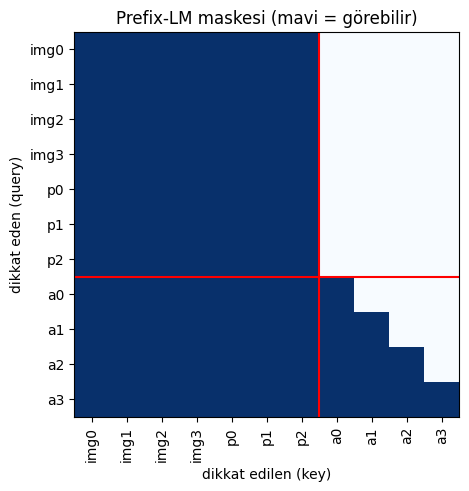

In [8]:
n_img, n_txt, n_ans = 4, 3, 4
n_pre, N = n_img + n_txt, n_img + n_txt + n_ans
mask = torch.tril(torch.ones(N, N))   # causal
mask[:n_pre, :n_pre] = 1              # prefix kendi içinde tam dikkat

labels = [f"img{i}" for i in range(n_img)] + [f"p{i}" for i in range(n_txt)] + [f"a{i}" for i in range(n_ans)]
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="Blues")
plt.xticks(range(N), labels, rotation=90); plt.yticks(range(N), labels)
plt.axhline(n_pre - .5, color="r"); plt.axvline(n_pre - .5, color="r")
plt.xlabel("dikkat edilen (key)"); plt.ylabel("dikkat eden (query)")
plt.title("Prefix-LM maskesi (mavi = görebilir)")
plt.show()

## 3. Altyazı: `caption en` ve `caption tr`

PaliGemma çok dilli WebLI verisiyle eğitildi. Görevin sonuna dil kodu ekleniyor.
Ek bir görev: `describe` ile daha uzun bir betimleme.

In [9]:
for name in ["kediler", "salon", "araba", "ari"]:
    print(f"── {name}")
    print("  EN      :", ask(imgs[name], "caption en"))
    print("  TR      :", ask(imgs[name], "caption tr"))
    print("  describe:", ask(imgs[name], "describe tr", max_new_tokens=150))

── kediler
  EN      : Two cats are sleeping on a pink blanket with two remotes.
  TR      : Iki kedi uzaktan kumandaların yanında bir kanepede yatıyor.
  describe: Iki kedi uzaktan kumandaların yanında bir kanepede yatıyor.
── salon
  EN      : A woman standing in a kitchen next to a table.
  TR      : Bir kadın mutfakta yemek masasında duruyor.
  describe: Bir kadın mutfakta yemek masasında duruyor.
── araba
  EN      : A blue Volkswagen Beetle parked on the side of a street.
  TR      : Bir binanın önüne park etmiş küçük bir araba.
  describe: Bir binanın önüne park etmiş küçük bir araba.
── ari
  EN      : A bee is on a flower with red flowers in the background.
  TR      : Invertebrate on a flower in a garden.
  describe: In this image we can see some flowers and leaves.


**Blog için gözlem:** Türkçe altyazıların dil bilgisi ve ayrıntı düzeyi İngilizce olanlarla aynı mı? Hangi görselde ayrışıyorlar?

## 4. Görsel soru-cevap (VQA)

Biçim: `answer <dil> <soru>`. Sayma, renk ve konum soruları soruyoruz. Modelin yanıldığı yerler, doğru cevapladığı yerlerden daha öğretici.

In [10]:
qa = [
    ("kediler", "answer en how many cats are there?"),
    ("kediler", "answer en what color is the couch?"),
    ("kediler", "answer en what is next to the cats?"),
    ("salon",   "answer en is there a television in the room?"),
    ("salon",   "answer en how many people are in the room?"),
    ("salon",   "answer tr odada kaç sandalye var?"),
    ("araba",   "answer en what color is the car?"),
]
for name, q in qa:
    print(f"[{name}] {q}\n   → {ask(imgs[name], q, max_new_tokens=20)}")

[kediler] answer en how many cats are there?
   → 2
[kediler] answer en what color is the couch?
   → pink
[kediler] answer en what is next to the cats?
   → remotes
[salon] answer en is there a television in the room?
   → yes
[salon] answer en how many people are in the room?
   → 2
[salon] answer tr odada kaç sandalye var?
   → 4
[araba] answer en what color is the car?
   → blue


## 6. Nesne tespiti: `detect ...`

*(5. örnekte çözünürlük değiştirmek için model yeniden yükleniyor; bu yüzden OCR'ı en sona aldım.)*

PaliGemma'da ayrı bir tespit kafası yok. Kutular da **metin token'ı** olarak üretiliyor:

```
<loc0123><loc0456><loc0789><loc0999> cat ; <loc....>... remote
```

Her nesne için 4 token var: **y_min, x_min, y_max, x_max**. Her biri 0–1023 arasında, görselin boyutuna göre normalize edilmiş bir koordinat. Birden fazla sınıf sorulacaksa sınıflar ` ; ` ile ayrılıyor.

In [11]:
def parse_detections(text, w, h):
    """'<locYYYY>x4 etiket ; ...' biçimini [(etiket, (x0, y0, x1, y1)), ...] listesine çevirir."""
    out = []
    for m in re.finditer(r"((?:<loc\d{4}>){4})\s*([^;<]+)", text):
        y0, x0, y1, x1 = [int(v) / 1024 for v in re.findall(r"\d{4}", m.group(1))]
        out.append((m.group(2).strip(), (x0 * w, y0 * h, x1 * w, y1 * h)))
    return out

# Küçük kontrol: parser bozulursa burası hata verir
_t = "<loc0000><loc0000><loc0512><loc0256> cat ; <loc0100><loc0200><loc0300><loc0400> remote"
assert parse_detections(_t, 1024, 1024) == [("cat", (0, 0, 256, 512)), ("remote", (200, 100, 400, 300))]

def draw(img, dets):
    im = img.copy(); d = ImageDraw.Draw(im)
    for label, box in dets:
        d.rectangle(box, outline="red", width=4)
        d.text((box[0] + 4, box[1] + 4), label, fill="red")
    return im

[kediler] detect cat ; remote control
   ham çıktı: <loc0159><loc0068><loc0250><loc0285> remote control ; <loc0053><loc0545><loc0800><loc1022> cat ; <loc0114><loc0020><loc1012><loc0508> cat ; <loc0163><loc0535><loc0394><loc0588> remote control
[salon] detect person ; chair ; tv
   ham çıktı: <loc0517><loc0472><loc0761><loc0563> chair ; <loc0517><loc0641><loc0730><loc0708> chair ; <loc0521><loc0570><loc0753><loc0664> chair ; <loc0374><loc0669><loc0714><loc0742> person ; <loc0396><loc0010><loc0644><loc0246> tv ; <loc0521><loc0471><loc0730><loc0558> chair
[ari] detect bee ; flower
   ham çıktı: <loc0000><loc0000><loc1022><loc0981> flower ; <loc0471><loc0453><loc0627><loc0561> bee


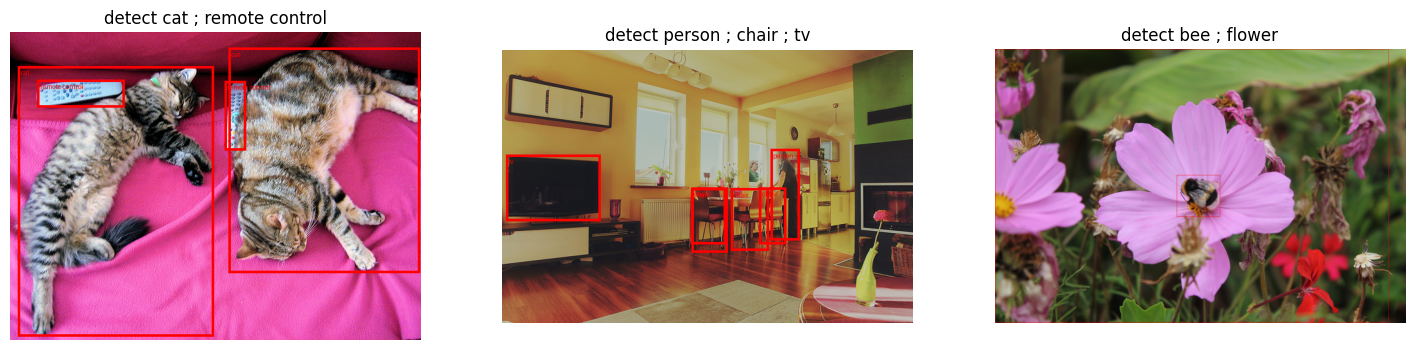

In [12]:
jobs = [("kediler", "detect cat ; remote control"),
        ("salon",   "detect person ; chair ; tv"),
        ("ari",     "detect bee ; flower")]

fig, axes = plt.subplots(1, len(jobs), figsize=(18, 6))
for ax, (name, prompt) in zip(axes, jobs):
    raw = ask(imgs[name], prompt, raw=True)
    print(f"[{name}] {prompt}\n   ham çıktı: {raw}")
    dets = parse_detections(raw, *imgs[name].size)
    ax.imshow(draw(imgs[name], dets)); ax.set_title(prompt); ax.axis("off")
plt.show()

**Blog için mesaj:** Tespit, altyazı ve OCR aynı modelde, aynı kayıp fonksiyonuyla (bir sonraki token'ı tahmin etme) yapılıyor. Değişen tek şey çıktı sözlüğüne eklenmiş 1024 adet `<loc>` token'ı.
*(Segmentasyon da `<seg>` token'larıyla aynı şekilde çalışıyor, ama maskeyi çözmek için ayrı bir VQ-VAE decoder gerektiği için burada atlandı.)*

## 5. OCR: Türkçe karakterler ve çözünürlük

Önce PIL ile içinde **ğ, ş, ı, İ, ç, ö, ü** geçen sentetik bir tabela çiziyoruz. Böylece doğru cevabı biliyoruz.
İstersen bir sonraki hücreyle kendi fotoğrafını (tabela, fiş, menü) da yükleyebilirsin.

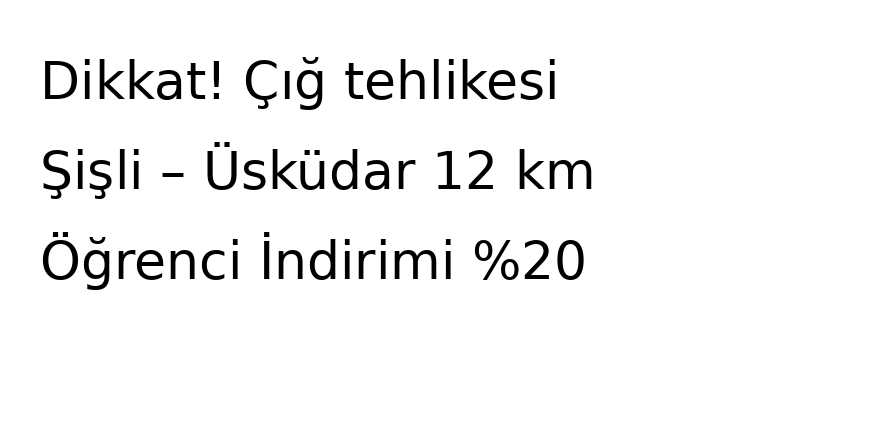

In [13]:
from matplotlib import font_manager
font_path = font_manager.findfont("DejaVu Sans")

def tabela(lines, size=(896, 448)):
    im = Image.new("RGB", size, "white"); d = ImageDraw.Draw(im)
    f = ImageFont.truetype(font_path, 52)
    for i, line in enumerate(lines):
        d.text((40, 50 + i * 90), line, fill="black", font=f)
    return im

GERCEK = ["Dikkat! Çığ tehlikesi", "Şişli – Üsküdar 12 km", "Öğrenci İndirimi %20"]
imgs["tabela"] = tabela(GERCEK)
imgs["tabela"]

In [15]:
# İsteğe bağlı: kendi fotoğrafını yükle (tabela, fiş, menü...). Atlamak için bu hücreyi çalıştırma.
imgs["fis1"] = Image.open("/content/fis1.jpeg").convert("RGB")
imgs["fis2"] = Image.open("/content/fis2.jpeg").convert("RGB")
imgs["fis3"] = Image.open("/content/fis3.jpeg").convert("RGB")

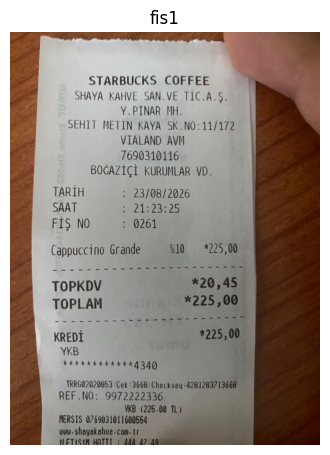

[fis1] ocr
  → STARBUCKS COFFEE SHAYA KAHVE SAN.VE TİC.A.Ş. Y.PINAR MH.
SEHIT METIN KAYA SK.NO:11/172 VIALAND AVM
7690310116
BOGAZİÇİ KURUMLAR VD.
TARİH
: 23/08/2026
SAAT
: 21:23:25
FİŞ NO
: 0261
%10 *225,00
Cappuccino Grande
*20,45
TOPKDV
*225,00
TOPLAM
*225,00
KREDİ
YKB
*4340
TRG02020853 Çek: 3668 Checkseq: 4281283713668
REF. NO: 9972222336
YKB (225,00 TL)
MERSIS 0769031011000554
www.shayakahove.com
HLETİSİM HATTI: 444.47.49



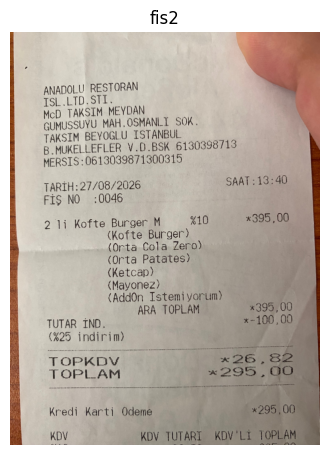

[fis2] ocr
  → ANADOLU RESTORAN
ISL. LTD. Şİİ.
Mcd TAKSİM MEVDAN
GUMUŞUYU MAH. OŞMANLI SOK.
TAKSİM BEYOGLU, İSTANBUL
B.MUKELLEFLER V.D. BSK 6130398713
MERSIS: 0613039871300315
SAAT 13:40
TARİH: 27/08/2026
Fiş NO :0046
*395.00
%10
2 11 Kofte Burger M
(Kofte Burger)
(Orta Cola Zero)
(Orta Patates)
(Ketcap)
(Mayonez)
(AddOn İstemiyorum)
*395.00
ARA TOPLAM
*100.00
TUTAR İND.
(%) İndirim)
*26.82
TOPKDV
*295.00
TOPLAM
*295.00
Kredi Karti Ödeme
KDV TUTARI KDV'Lİ TOPLAM
KDV



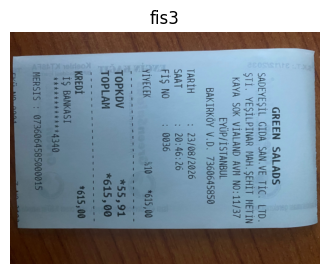

[fis3] ocr
  → KÖŞÜK YERLEK
YİYECEK
KREDİ
YİYECEK
FİŞ NO
TAHİH
SAAT
TOPLAM
KREDİ
SİTİ: YENŞİLPINAR MAH. ŞEHİ METİN
HERSİ : 073606456500015
SADEYEŞİL CİDA SAN. VE T.C. LTD.
KAYA SOK. VİALAND AVM NO: 11/37 EVÜP İSTANBUL
TOPLKV
15 BİNKASI
: 07360645650
: 23/08/2026
: 0036
%10
*615,00
*55,91
*615,00
*615,00



In [16]:
FISLER = ["fis1", "fis2", "fis3"]
PROMPT = "ocr"          # ← sadece bunu değiştir
MAX_TOKENS = 300        # fişler uzun; cevap yarıda kesilirse artır

ocr_448 = {}
for k in FISLER:
     plt.figure(figsize=(4, 6)); plt.imshow(imgs[k]); plt.title(k); plt.axis("off"); plt.show()
     ocr_448[k] = ask(imgs[k], PROMPT, max_new_tokens=MAX_TOKENS)
     print(f"[{k}] {PROMPT}\n  → {ocr_448[k]}\n")